# **NEUROCHIP SMART FAULT MAPPER**

### Detect and pinpoint faults in a VLSI design using a Graphical Neural Network.

Author: Nikhil Bhaktha

GitHub Profile: [GlobosNik](https://github.com/GlobosNik)

---
# **GNN Trainer Notebook**

## Load the required python modules

In [1]:
# Install pytorch geometric for GNN
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 26.0 MB/s eta 0:00:00


In [2]:
import os, re, ast, copy, enum, warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, global_max_pool
from torch_geometric.data import Data, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score)

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {DEVICE}")

[INFO] Using device: cuda


### Load the CSV files for GNN Training

In [3]:
DATA_DIR = "."

node_list, status_list, edges_list = [], [], []
for phase in [1, 2, 3, 4]:
    nf = os.path.join(DATA_DIR, f"nodesData_{phase}.csv")
    sf = os.path.join(DATA_DIR, f"statusData_{phase}.csv")
    ef = os.path.join(DATA_DIR, f"edgesData_{phase}.csv")
    if not all(os.path.exists(p) for p in [nf, sf, ef]):
        print(f"[WARN] Phase {phase} files missing — skipping.")
        continue
    node_list.append(pd.read_csv(nf))
    status_list.append(pd.read_csv(sf))
    edges_list.append(pd.read_csv(ef))

nodesData  = pd.concat(node_list,  ignore_index=True)
statusData = pd.concat(status_list, ignore_index=True)
edgesData  = pd.concat(edges_list,  ignore_index=True)

nodesData  = nodesData.drop_duplicates(subset=["circuit_id", "node_id"])
edgesData  = edgesData.drop_duplicates(subset=["circuit_id", "src", "dst"])
statusData = statusData.drop_duplicates(subset=["circuit_id"])

print(f"[INFO] Loaded — nodes: {len(nodesData):,}  edges: {len(edgesData):,}  "f"circuits: {len(statusData):,}")

[INFO] Loaded — nodes: 308,264  edges: 465,698  circuits: 1,020


---
## NetworkX Graph Generation

In [4]:
NODE_FEATURE_COLS = [
    # One-hot gate / port type encoding  (11 dims)
    "type_input", "type_output", "type_assign",
    "type_and", "type_or", "type_not",
    "type_xor", "type_nor", "type_xnor",
    "type_buf", "type_inv",
    # Structural features  (4 dims)
    "is_port",
    "fanin_norm", "fanout_norm", "degree_norm",
]
NUM_NODE_FEATURES = len(NODE_FEATURE_COLS)   # = 15
print(f"[INFO] Node feature vector size: {NUM_NODE_FEATURES}")

# Verify all expected columns are present
missing = [c for c in NODE_FEATURE_COLS if c not in nodesData.columns]
if missing:
    raise ValueError(f"nodesData is missing expected columns: {missing}")

[INFO] Node feature vector size: 15


### Function to Generate NetworkX Graphs

In [ ]:
statusData = statusData.copy()
statusData["is_faulty"] = (
    (statusData["num_gates"] == 0) & (statusData["signal_map_len"] > 0)
).astype(int)

fault_counts = statusData["is_faulty"].value_counts()
print(f"[INFO] Fault label distribution — healthy: {fault_counts.get(0,0)}  "
      f"faulty: {fault_counts.get(1,0)}")

# Graph-level context features (circuit-level stats joined onto each graph)
GRAPH_FEATURE_COLS = [
    "signal_map_len", "num_gates", "num_inputs", "num_outputs",
    "avg_degree", "max_depth",
]
NUM_GRAPH_FEATURES = len(GRAPH_FEATURE_COLS)

# Parse the gate_types Counter string → dict
def parse_gate_types(raw: str) -> dict:
    """'Counter({\"buf\": 2, \"inv\": 1})' → {'buf': 2, 'inv': 1}"""
    try:
        return dict(eval(raw))
    except Exception:
        return {}

statusData["gate_types_dict"] = statusData["gate_types"].apply(parse_gate_types)

[INFO] Fault label distribution — healthy: 788  faulty: 232


- Build one directed NetworkX graph per `circuit_id`.
- Node attributes include all `NODE_FEATURE_COLS`.
- Edge direction follows src → dst (signal flow).

In [ ]:
def buildGraph(nodes_df: pd.DataFrame, edges_df: pd.DataFrame, circuit_ids: list) -> dict:
    graphs = {}
    for c_id in tqdm(circuit_ids, desc="Building NX graphs"):
        G = nx.DiGraph()

        #  nodes 
        n_subset = nodes_df[nodes_df["circuit_id"] == c_id]
        for _, row in n_subset.iterrows():
            attrs = {col: float(row[col]) for col in NODE_FEATURE_COLS}
            attrs["type"] = row["type"]          # keep string label too
            attrs["fanin"]  = int(row["fanin"])
            attrs["fanout"] = int(row["fanout"])
            G.add_node(int(row["node_id"]), **attrs)

        #  edges (src / dst are LOCAL node ids) 
        e_subset = edges_df[edges_df["circuit_id"] == c_id]
        for _, row in e_subset.iterrows():
            src, dst = int(row["src"]), int(row["dst"])
            if G.has_node(src) and G.has_node(dst):
                G.add_edge(src, dst)

        graphs[c_id] = G
    return graphs

- Return circuit IDs that exist in all three dataframes AND have at least one edge whose endpoints are both declared in `nodes_df`.
- Edges referencing undeclared nodes (cross-phase references) are silently dropped in `graphToPYG` rather than disqualifying the entire circuit.

In [ ]:
def getValidID(nodes_df, edges_df, status_df):
    common = (
        set(nodes_df["circuit_id"].unique())
        & set(edges_df["circuit_id"].unique())
        & set(status_df["circuit_id"].unique())
    )
    valid = []
    for c_id in common:
        nodes_in_df  = set(nodes_df[nodes_df["circuit_id"] == c_id]["node_id"])
        edges_subset = edges_df[edges_df["circuit_id"] == c_id]
        # Only count edges whose BOTH endpoints exist in this phase's node list
        valid_edges = edges_subset[
            edges_subset["src"].isin(nodes_in_df) &
            edges_subset["dst"].isin(nodes_in_df)
        ]
        if len(valid_edges) > 0 and len(nodes_in_df) >= 2:
            valid.append(c_id)
    return sorted(valid)

valid_ids = getValidID(nodesData, edgesData, statusData)
print(f"[INFO] Valid circuits for GNN training: {len(valid_ids)}")

# Build NX graphs only for valid circuits
circuit_graphs = buildGraph(nodesData, edgesData, valid_ids)

[INFO] Valid circuits for GNN training: 541


Building NX graphs: 100%|██████████| 541/541 [00:55<00:00,  9.70it/s] 


Convert a NetworkX graph to a PyG Data object.

| Variable | Type |
|-------------|----------------|
| `x`          | `float` tensor  [N, NUM_NODE_FEATURES] |
| `edge_index`  | `long` tensor   [2, E]  (COO format) |
| `y`           | `long` tensor   [1]     (graph-level fault label) |
| `graph_feats` | `float` tensor  [1, NUM_GRAPH_FEATURES]  (circuit stats) |
| `circuit_id`  | `int` |

In [ ]:
def graphToPYG(c_id: int, G: nx.DiGraph, nodes_df: pd.DataFrame, status_df: pd.DataFrame) -> Data:
    sorted_nodes = sorted(G.nodes())
    if not sorted_nodes:
        return None

    # Local mapping:  node_id (may be 0…N-1) → contiguous index 0…N-1
    nid_to_idx = {nid: idx for idx, nid in enumerate(sorted_nodes)}

    # Node feature matrix
    n_subset = nodes_df[nodes_df["circuit_id"] == c_id].set_index("node_id")
    rows = []
    for nid in sorted_nodes:
        if nid in n_subset.index:
            rows.append(n_subset.loc[nid, NODE_FEATURE_COLS].values.astype(np.float32))
        else:
            rows.append(np.zeros(NUM_NODE_FEATURES, dtype=np.float32))
    x = torch.tensor(np.array(rows), dtype=torch.float)

    # Edge index (COO)
    src_list, dst_list = [], []
    for u, v in G.edges():
        if u in nid_to_idx and v in nid_to_idx:
            src_list.append(nid_to_idx[u])
            dst_list.append(nid_to_idx[v])
    if not src_list:
        return None
    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)

    # Graph-level label
    status_row = status_df[status_df["circuit_id"] == c_id]
    if status_row.empty:
        return None
    y = torch.tensor([int(status_row["is_faulty"].values[0])], dtype=torch.long)

    # Graph-level context features (normalised later in the model)
    gf = status_row[GRAPH_FEATURE_COLS].values.astype(np.float32)
    graph_feats = torch.tensor(gf, dtype=torch.float)   # shape [1, 6]

    return Data(x=x, edge_index=edge_index, y=y,
                graph_feats=graph_feats, circuit_id=c_id)

pyg_data_list = []
for c_id in tqdm(valid_ids, desc="NX → PyG"):
    G = circuit_graphs[c_id]
    d = graphToPYG(c_id, G, nodesData, statusData)
    if d is not None:
        pyg_data_list.append(d)

print(f"[INFO] PyG dataset size: {len(pyg_data_list)}")
label_counts = Counter(int(d.y.item()) for d in pyg_data_list)
print(f"[INFO] Label distribution — healthy: {label_counts[0]}  "
      f"faulty: {label_counts[1]}")

NX → PyG: 100%|██████████| 541/541 [01:51<00:00,  4.84it/s]

[INFO] PyG dataset size: 541
[INFO] Label distribution — healthy: 475  faulty: 66


-----

## GNN Data Preprocessing and Model Training

In [9]:
labels = [d.y.item() for d in pyg_data_list]
train_data, test_data = train_test_split(
    pyg_data_list,
    test_size=0.2,
    random_state=42,
    stratify=labels
)
train_labels = [d.y.item() for d in train_data]
train_data, val_data = train_test_split(
    train_data,
    test_size=0.15,
    random_state=42,
    stratify=train_labels
)

print(f"[INFO] Split — train: {len(train_data)}  "
      f"val: {len(val_data)}  test: {len(test_data)}")

BATCH_SIZE = 32
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_data,   batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE)

[INFO] Split — train: 367  val: 65  test: 109


### GNN Model Structure:

Two-stage GNN for graph-level fault classification.

- **Stage 1 — Message passing (GCN):** 3 GCNConv layers with residual connections learn node embeddings that capture local structural context (gate type, fan-in/out, depth).

- **Stage 2 — Graph readout + classification:** Global mean + max pooling are concatenated with the circuit-level context features (`num_gates`, `avg_degree`, etc) and passed through an MLP to produce the final fault probability.

In [ ]:
class FaultGNN(nn.Module):
    def __init__(self, in_channels: int, hidden: int = 64, graph_feat_dim: int = NUM_GRAPH_FEATURES, num_classes: int = 2, dropout: float = 0.3):
        super().__init__()
        self.dropout = dropout

        #  GCN layers with residual connections 
        self.conv1 = GCNConv(in_channels, hidden)
        self.conv2 = GCNConv(hidden,      hidden)
        self.conv3 = GCNConv(hidden,      hidden)

        # Residual projection if in_channels ≠ hidden
        self.res_proj = (nn.Linear(in_channels, hidden)
                         if in_channels != hidden else nn.Identity())

        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden)
        self.bn3 = nn.BatchNorm1d(hidden)

        #  Graph-feature branch (circuit-level stats) 
        self.gf_fc = nn.Sequential(
            nn.Linear(graph_feat_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
        )

        #  Classifier MLP
        # Pooling produces 2 × hidden; graph-feat branch adds 32
        clf_in = 2 * hidden + 32
        self.clf = nn.Sequential(
            nn.Linear(clf_in, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes),
        )

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        #  Message passing 
        x0 = self.res_proj(x)

        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.relu(self.bn2(self.conv2(x, edge_index))) + x   # residual
        x = F.dropout(x, p=self.dropout, training=self.training)

        x = F.relu(self.bn3(self.conv3(x, edge_index))) + x   # residual

        #  Global pooling ─
        g_mean = global_mean_pool(x, batch)    # [B, hidden]
        g_max  = global_max_pool(x,  batch)    # [B, hidden]
        g = torch.cat([g_mean, g_max], dim=1)  # [B, 2*hidden]

        #  Graph-level context features 
        gf = data.graph_feats                  # [B, graph_feat_dim]
        if gf.dim() == 3:                      # squeeze if [B,1,D]
            gf = gf.squeeze(1)
        gf_emb = self.gf_fc(gf)               # [B, 32]

        #  Classification ─
        out = self.clf(torch.cat([g, gf_emb], dim=1))
        return out

    @torch.no_grad()
    def node_fault_scores(self, data) -> torch.Tensor:
        """
        Returns a per-node 'suspicion score' in [0, 1].
        Nodes whose embeddings deviate most from the graph mean are flagged.
        Useful for fault localisation in new Verilog files.
        """
        self.eval()
        x, edge_index = data.x.to(DEVICE), data.edge_index.to(DEVICE)
        x0 = self.res_proj(x)
        x  = F.relu(self.bn1(self.conv1(x, edge_index)))
        x  = F.relu(self.bn2(self.conv2(x, edge_index))) + x
        x  = F.relu(self.bn3(self.conv3(x, edge_index))) + x
        # Distance of each node embedding from the graph centroid
        centroid = x.mean(dim=0, keepdim=True)
        scores   = torch.norm(x - centroid, dim=1)
        scores   = (scores - scores.min()) / (scores.max() - scores.min() + 1e-8)
        return scores.cpu()


model = FaultGNN(in_channels=NUM_NODE_FEATURES).to(DEVICE)
print(f"[INFO] Model parameters: "
      f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

[INFO] Model parameters: 41,026


Training Function

In [11]:
class_counts = torch.tensor(
    [label_counts[0], label_counts[1]], dtype=torch.float)
class_weights = (class_counts.sum() / (2.0 * class_counts)).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", patience=5, factor=0.5, min_lr=1e-6)


def runEpoch(loader, train: bool):
    model.train(train)
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    ctx = torch.enable_grad if train else torch.no_grad
    with ctx():
        for batch in loader:
            batch = batch.to(DEVICE)
            if train:
                optimizer.zero_grad()
            logits = model(batch)
            loss   = criterion(logits, batch.y)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * batch.num_graphs
            preds  = logits.argmax(dim=1)
            correct += (preds == batch.y).sum().item()
            total   += batch.num_graphs
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(batch.y.cpu().tolist())
    avg_loss = total_loss / total
    acc      = correct / total
    try:
        auc = roc_auc_score(all_labels, all_preds)
    except Exception:
        auc = float("nan")
    return avg_loss, acc, auc

Training and Evaluation of the GNN

In [ ]:
EPOCHS       = 100
PATIENCE     = 15
best_val_acc = 0.0
best_model   = None
history      = {"train_loss": [], "val_loss": [], "train_acc":  [], "val_acc":  []}
no_improve   = 0

print("\n[INFO] Starting training …")
for epoch in range(1, EPOCHS + 1):
    t_loss, t_acc, _ = runEpoch(train_loader, train=True)
    v_loss, v_acc, v_auc = runEpoch(val_loader, train=False)
    scheduler.step(v_acc)

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    if v_acc > best_val_acc:
        best_val_acc = v_acc
        best_model   = copy.deepcopy(model.state_dict())
        no_improve   = 0
    else:
        no_improve += 1

    if epoch % 10 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]["lr"]
        print(f"  Epoch {epoch:03d}/{EPOCHS}  train_loss={t_loss:.4f}  val_loss={v_loss:.4f}  val_acc={v_acc:.4f}  val_auc={v_auc:.4f}  lr={lr:.2e}")

    if no_improve >= PATIENCE:
        print(f"[INFO] Early stopping at epoch {epoch} (no val improvement for {PATIENCE} epochs).")
        break

# Restore best checkpoint
model.load_state_dict(best_model)
torch.save(best_model, "NeuroChip.pt")
print(f"[INFO] Best model saved"
      f"(val_acc={best_val_acc:.4f})")


[INFO] Starting training …
  Epoch 001/100  train_loss=0.8732  val_loss=0.6215  val_acc=0.5692  val_auc=0.5932  lr=1.00e-03
  Epoch 010/100  train_loss=1.4104  val_loss=0.2938  val_acc=0.9231  val_auc=0.9561  lr=1.00e-03
  Epoch 020/100  train_loss=0.4490  val_loss=0.1613  val_acc=0.9385  val_auc=0.9649  lr=5.00e-04
  Epoch 030/100  train_loss=0.1746  val_loss=0.2097  val_acc=0.9231  val_auc=0.9561  lr=2.50e-04
  Epoch 040/100  train_loss=0.1579  val_loss=0.0695  val_acc=0.9846  val_auc=0.9912  lr=1.25e-04
[INFO] Early stopping at epoch 46 (no val improvement for 15 epochs).
[INFO] Best model saved(val_acc=1.0000)


----

## Plot Metrics

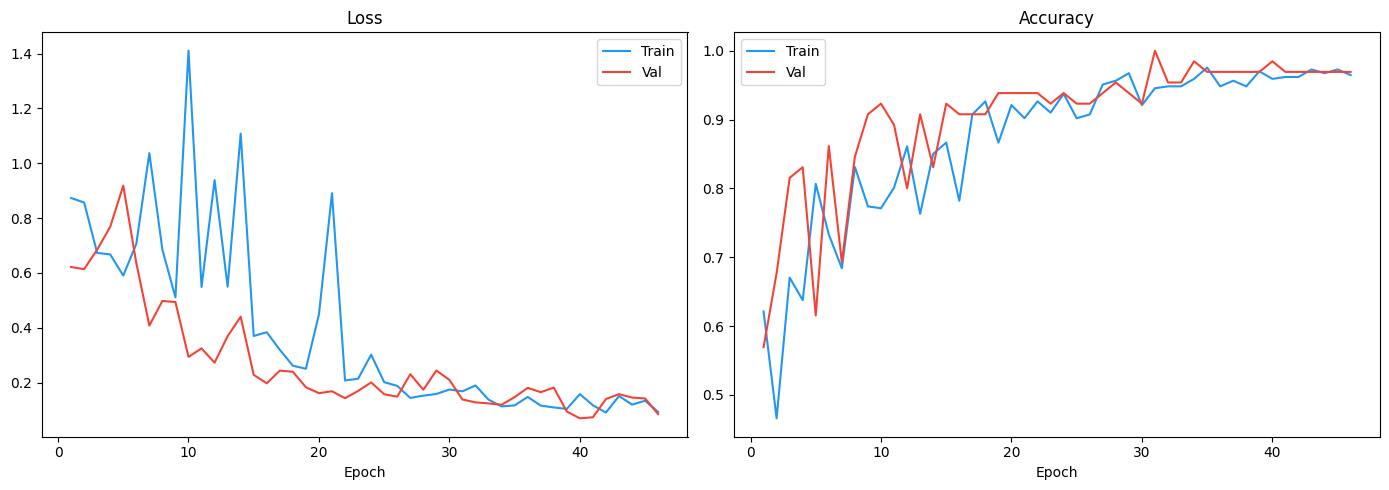

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs_ran = range(1, len(history["train_loss"]) + 1)
ax1.plot(epochs_ran, history["train_loss"], label="Train", color="#2196F3")
ax1.plot(epochs_ran, history["val_loss"],   label="Val",   color="#F44336")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()
ax2.plot(epochs_ran, history["train_acc"], label="Train", color="#2196F3")
ax2.plot(epochs_ran, history["val_acc"],   label="Val",   color="#F44336")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()


[RESULT] Test  acc=0.9541  auc=0.9075  loss=1.4561

[RESULT] Classification Report:
              precision    recall  f1-score   support

     Healthy       0.98      0.97      0.97        96
      Faulty       0.79      0.85      0.81        13

    accuracy                           0.95       109
   macro avg       0.88      0.91      0.89       109
weighted avg       0.96      0.95      0.95       109



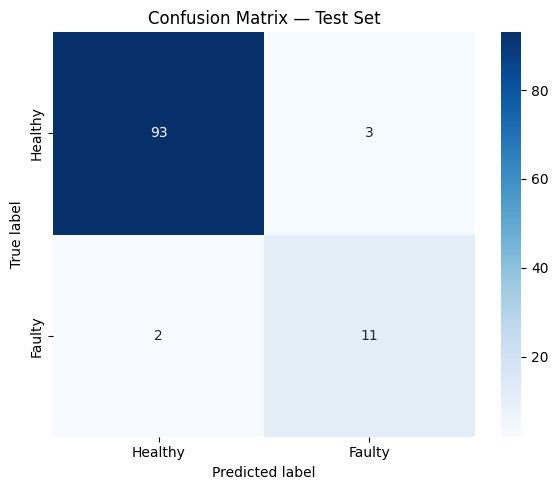

In [ ]:
test_loss, test_acc, test_auc = runEpoch(test_loader, train=False)
print(f"\n[RESULT] Test  acc={test_acc:.4f}  auc={test_auc:.4f}  "
      f"loss={test_loss:.4f}")

# Detailed classification report
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for batch in test_loader:
        batch = batch.to(DEVICE)
        preds = model(batch).argmax(dim=1)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(batch.y.cpu().tolist())

print("\n[RESULT] Classification Report:")
print(classification_report(all_labels, all_preds, labels=[0, 1], target_names=["Healthy", "Faulty"], zero_division=0))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Healthy", "Faulty"], yticklabels=["Healthy", "Faulty"])
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()